## NISAR Pixel Conversion 

This notebook converts sample ground truth data coordinates (latitude and longitude) into corresponding NISAR raster pixel indices. Identifying the correct pixel location for each site allows direct extraction of NISAR data values at field observation points.

The workflow includes transforming geographic coordinates into the NISAR product’s coordinate system, locating the nearest raster pixel, and storing the associated row and column indices for analysis. The resulting site locations and pixel footprints are also visualized on an interactive Folium map to confirm alignment between ground sites and the NISAR raster grid.

## Ground Truth Site

## About Lake Afrera 

::: {dropdown} Location and Setting

Lake Afrera (also known as Lake Giulietti) is located in northeastern Ethiopia within the Danakil Depression, one of the lowest and hottest places on Earth. The lake sits in the Afar Region, near the border with Eritrea, at an elevation of approximately −100 meters below sea level.


The Danakil Depression lies within the Afar Triple Junction, where the African, Arabian, and Somali tectonic plates are actively pulling apart. This rifting environment creates intense volcanic and geothermal activity throughout the region.

:::

::: {dropdown} Why Lake Afrera Is Hypersaline?

Lake Afrera is a hypersaline lake, meaning its salinity is significantly higher than that of normal seawater. Its high salinity results from several factors:

- Closed basin hydrology: The lake has no outlet to the ocean, so dissolved salts accumulate over time.

- Extreme evaporation: The Danakil Depression experiences very high temperatures and low rainfall, causing water to evaporate rapidly.

- Hydrothermal inputs: Nearby geothermal systems and volcanic activity contribute mineral-rich fluids.

As water evaporates, salts such as halite (sodium chloride) precipitate and form crusts and salt flats around the lake margins. These processes create strong contrasts in surface roughness and reflectivity, which are visible in radar imagery.
:::

::: {dropdown} Surface Features and Radar Relevance

Lake Afrera and its surrounding landscape display strong contrasts in surface texture that are particularly visible in radar data. The region includes open water (typically dark in radar imagery), bright salt crusts and evaporite deposits, mud flats that vary seasonally, and geometric salt extraction ponds.

The lake is also bordered by volcanic cones, basaltic lava flows, and geothermal areas associated with the Afar rift system. This mix of water, salt, sediment, and volcanic rock creates a highly heterogeneous surface within a relatively small area.

These sharp contrasts in roughness, moisture, and dielectric properties make Lake Afrera an excellent natural laboratory for studying radar backscatter variability and polarization-dependent scattering behavior.
:::

In [1]:
#imports
import numpy as np
from pyproj import Transformer
import h5py
import matplotlib.pyplot as plt
from pyproj import Transformer
import branca.colormap as cm

In [2]:
#define raster path
raster_path = "NISAR_L2_PR_GCOV_006_172_A_008_2005_DHDH_A_20251204T024618_20251204T024653_X05007_N_F_J_001.h5"

In [3]:
#define sites
#these coordinates are in EPSG 4326
sites = {
    "Salt_Ponds":          (13.25889, 40.85111),
    "Hypersaline_Lake":    (13.26028, 40.89972),
    "Afdera_Volcano":      (13.08833, 40.85250),
    "Sand_Plains":         (13.27944, 40.80694),
    "Afdera_Lava_Field":   (13.09222, 40.72583),
    "Borawli_Caldera":     (13.30389, 40.98972),
    "Borawli_Lava_Field":  (13.21833, 40.98056),
}

#### Locate Relevant GCOV data

In [4]:
#path to the NISAR GCOV HDF5 file
h5_path = "NISAR_L2_PR_GCOV_006_172_A_008_2005_DHDH_A_20251204T024618_20251204T024653_X05007_N_F_J_001.h5"

#GCOV data are stored under the "grids" groups
#select desired frequency: "frequencyA" or "frequencyB"
freq = "frequencyA"
grid_grp = f"/science/LSAR/GCOV/grids/{freq}"

#for this example, we will be using the HHHHH layer 
#for this GCOV file, different layers are available and listed in the output below.
layer = "HHHH"
layer_path = f"{grid_grp}/{layer}"

#print paths 
print("File:", h5_path)
print("Grid group:", grid_grp)
print("Current raster layer:", layer_path)

#examine available GCOV datasets within this file:
with h5py.File(h5_path, "r") as f:
    print("\nAvailable GCOV datasets:")
    for k in f[grid_grp].keys():
        print(" ", k)

File: NISAR_L2_PR_GCOV_006_172_A_008_2005_DHDH_A_20251204T024618_20251204T024653_X05007_N_F_J_001.h5
Grid group: /science/LSAR/GCOV/grids/frequencyA
Current raster layer: /science/LSAR/GCOV/grids/frequencyA/HHHH

Available GCOV datasets:
  HHHH
  HVHV
  listOfCovarianceTerms
  listOfPolarizations
  mask
  numberOfLooks
  numberOfSubSwaths
  projection
  rtcGammaToSigmaFactor
  xCoordinateSpacing
  xCoordinates
  yCoordinateSpacing
  yCoordinates


#### Identify the coordinate system used by GCOV

In [5]:
#open the GCOV file (in read mode) to read coordinate and spatial information 
with h5py.File(h5_path, "r") as f:

    #in a GCOV file, the "projection" dataset stores coordinate systems
    #the output value will  be an EPSG code     
    epsg = int(f[f"{grid_grp}/projection"][()])

    #xCoordinates and yCoordinates are arrays that store the coordinates of each pixel center
    #these coordinates will later be used to center pixel footprints  
    x = f[f"{grid_grp}/xCoordinates"][:]
    y = f[f"{grid_grp}/yCoordinates"][:]

    #CoordinateSpacing values store the pixel size in meters 
    #this will later be used to map the pixel footprint
    dx = float(f[f"{grid_grp}/xCoordinateSpacing"][()])
    dy = float(f[f"{grid_grp}/yCoordinateSpacing"][()])

#print information
print("GCOV coordinate system (EPSG):", epsg)
print("Raster size:", len(y), "rows x", len(x), "columns")
print("Pixel size:", dx, "m (x) ×", dy, "m (y)")

GCOV coordinate system (EPSG): 32637
Raster size: 16704 rows x 17064 columns
Pixel size: 20.0 m (x) × -20.0 m (y)


#### Convert ground truth site locations to GCOV pixel coordinates

In [6]:
#use transformer to convert ground truth data (EPSG 4326) coordinate system to GCOV coordinate system (EPSG 32637)
transformer = Transformer.from_crs(
    "EPSG:4326",
    f"EPSG:{epsg}",
    always_xy=True
)

site_pixels = {}

for name, (lat, lon) in sites.items():
    #convert the site location into GCOV map coordinates
    x_site, y_site = transformer.transform(lon, lat)

    #find the nearest GCOV pixel by comparing with the grid coordinates
    col = int(np.argmin(np.abs(x - x_site)))
    row = int(np.argmin(np.abs(y - y_site)))

    #store the GCOV pixel index for this site
    site_pixels[name] = (row, col)

#GCOV pixel indices corresponding to each site
site_pixels

{'Salt_Ponds': (6090, 4823),
 'Hypersaline_Lake': (6080, 5087),
 'Afdera_Volcano': (7034, 4838),
 'Sand_Plains': (5978, 4583),
 'Afdera_Lava_Field': (7017, 4151),
 'Borawli_Caldera': (5835, 5573),
 'Borawli_Lava_Field': (6309, 5527)}

#### Create Folium map with:
- HHHH overlay + HVHV overlay
- ground truth site markers (blue)
- GCOV pixel footprints (yellow)
- Additional tools: measure tool, mouse coordinates, layer toggle

This code uses the following variables from previous cells:
- h5_path, grid_grp, epsg, x, y, dx, dy, sites, site_pixels


In [7]:
!pip install folium

  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
Using cached folium-0.20.0-py2.py3-none-any.whl (113 kB)


Stretched display range (2–98% percentile):
vmin = 0.0009728094935417175
vmax = 0.31600227355957017



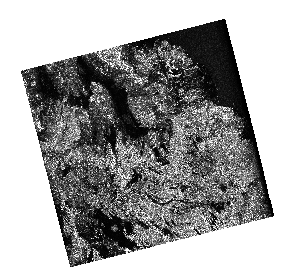
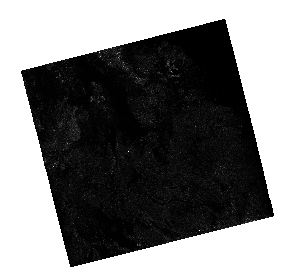

In [8]:
import folium
from folium.raster_layers import ImageOverlay
from folium.plugins import MeasureControl, MousePosition

################## Display / quicklook settings
#downsample factor for faster visualization 
#the "step" variable tells Python to read every Nth pixel in both row and column directions 
step = 60

#overlay transparency (0 = invisible, 1 = opaque)
overlay_opacity = 0.55

################# Convert coordinates into lat/lon for Folium use
# Folium expects WGS84 lat/lon (EPSG:4326).
to_ll = Transformer.from_crs(f"EPSG:{epsg}", "EPSG:4326", always_xy=True)

################ Read downsampled arrays (HHHH + HVHV) for quicklooks
#note: this does NOT change the original data in the HDF5 file
with h5py.File(h5_path, "r") as f:

    #read downsampled polarization arrays for display
    hh_q = np.array(f[f"{grid_grp}/HHHH"][::step, ::step], dtype=float)
    hv_q = np.array(f[f"{grid_grp}/HVHV"][::step, ::step], dtype=float)

    #read downsampled coordinate arrays (meters)
    #these are used to place the overlay in the correct geographic location
    xq = f[f"{grid_grp}/xCoordinates"][::step]
    yq = f[f"{grid_grp}/yCoordinates"][::step]

################# Stretch display settings to allow easier visualization 
#this affects visualization only — the original GCOV data are unchanged.
#using a single shared vmin/vmax ensures that both polarizations use the same
#brightness scale, preventing misleading visual comparisons between HHHH and HVHV
stack = np.concatenate([hh_q[np.isfinite(hh_q)], hv_q[np.isfinite(hv_q)]])
vmin = np.nanpercentile(stack, 2)
vmax = np.nanpercentile(stack, 98)

print("Stretched display range (2–98% percentile):")
print("vmin =", vmin)
print("vmax =", vmax)

################# Convert GCOV rasters to RGBA image 
#folium cannot overlay the GCOV rasters in their current format, so they must 
#be converted to RGBA images for visualization 
def arr_to_rgba(arr, vmin, vmax):
    #mask missing values
    finite = np.isfinite(arr)

    #clip to display range
    arr_clip = np.clip(arr, vmin, vmax)

    #normalize to 0–1 for colormap
    norm = (arr_clip - vmin) / (vmax - vmin + 1e-12)
    norm = np.nan_to_num(norm, nan=0.0)

    #map to RGBA using grayscale
    rgba = plt.cm.gray(norm)

    #set alpha channel to transparent for NaNs
    rgba[..., 3] = finite.astype(float) * 0.85
    return rgba

#convert both polarizations to RGBA using the same stretch
rgba_hh = arr_to_rgba(hh_q, vmin, vmax)
rgba_hv = arr_to_rgba(hv_q, vmin, vmax)

################# Compute overlay bounds (lat/lon) from GCOV x/y (meters)
#ImageOverlay requires SW/NE bounds in lat/lon
xmin, xmax = float(xq.min()), float(xq.max())
ymin, ymax = float(yq.min()), float(yq.max())

lon_sw, lat_sw = to_ll.transform(xmin, ymin)
lon_ne, lat_ne = to_ll.transform(xmax, ymax)

bounds = [[lat_sw, lon_sw], [lat_ne, lon_ne]]

################# Center Folium map over ground truth sites 
center_lat = sum(lat for lat, lon in sites.values()) / len(sites)
center_lon = sum(lon for lat, lon in sites.values()) / len(sites)

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=8,
    tiles="Esri.WorldImagery"
)

################# Add toggleable overlays 
ImageOverlay(
    image=rgba_hh,
    bounds=bounds,
    opacity=overlay_opacity,
    name="HHHH",
    interactive=True,
    zindex=2
).add_to(m)

ImageOverlay(
    image=rgba_hv,
    bounds=bounds,
    opacity=overlay_opacity,
    name="HVHV",
    interactive=True,
    zindex=2
).add_to(m)

################# Add ground truth sites and GCOV pixel footprints to map
sites_fg = folium.FeatureGroup(name="Ground Truth Sites", show=True)
pix_fg   = folium.FeatureGroup(name="GCOV Pixel Footprints", show=True)

for name, (lat, lon) in sites.items():

    #groundn truth site marker (blue)
    folium.Marker(
        location=[lat, lon],
        popup=f"{name}",
        icon=folium.Icon(color="blue")
    ).add_to(sites_fg)

    #pixel footprint (yellow)
    row, col = site_pixels[name]

    #pixel center coordinates
    x_center = float(x[col])
    y_center = float(y[row])

    #pixel corners (in meters)
    corners_xy = [
        (x_center - dx/2, y_center - dy/2),
        (x_center + dx/2, y_center - dy/2),
        (x_center + dx/2, y_center + dy/2),
        (x_center - dx/2, y_center + dy/2),
        (x_center - dx/2, y_center - dy/2),
    ]

    #convert corners to lat/lon for folium
    corners_latlon = []
    for xc, yc in corners_xy:
        lonp, latp = to_ll.transform(xc, yc)
        corners_latlon.append([latp, lonp])

    folium.Polygon(
        locations=corners_latlon,
        color="yellow",
        weight=2,
        fill=False,
        popup=f"{name}"
    ).add_to(pix_fg)

sites_fg.add_to(m)
pix_fg.add_to(m)

################# Add Legend
colormap = cm.linear.Greys_09.scale(vmin, vmax)
colormap.caption = "GCOV backscatter (shared stretch)"
colormap.add_to(m)

################# Add interactive tools 
MeasureControl(position="topleft").add_to(m)     #measure distance/area
MousePosition(position="bottomleft").add_to(m)  #display lat/lon for cursor 
m.add_child(folium.LatLngPopup())               #click map to get lat/lon popup 

#keep control panel open
folium.LayerControl(collapsed=False).add_to(m)

m